## NYC Taxi Fare Prediction

**Objective**

Predict the fare amount for NYC taxi rides using trip features such as distance, time, and passenger count.

**Dataset**

Source : New York City Taxi Fare Prediction - Kaggle Competition
(/kaggle/input/new-york-city-taxi-fare-prediction)

**Techniques Used**

* Data cleaning and feature engineering.
* Exploratory data analysis.
* Linear Regression and Random Forest Models.
* Model evaluation using MAE, RMSE, and R² metrics.
* Model saving for deployment.

In [1]:
#Basic Setup
#Core
import pandas as pd
import numpy as np
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Settings
import warnings
warnings.filterwarnings('ignore')
#Aesthetics
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 50)
#Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Basic Setup Complete")

Basic Setup Complete


In [2]:
#Loading a manageable subset for exploration
TRAIN_PATH = "/kaggle/input/new-york-city-taxi-fare-prediction/train.csv"
N_ROWS = 100000
df = pd.read_csv(TRAIN_PATH, nrows=N_ROWS)
print(df.shape)
df.head()

(100000, 8)


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [3]:
# Loose NYC bounding box constants
#We will use these in cleaning to cut obvious geo outliers
NYC_LAT_MIN, NYC_LAT_MAX = 40.3, 41.2
NYC_LON_MIN, NYC_LON_MAX = -74.5, -72.8

print("NYC bounds ready.")

NYC bounds ready.


**Dataset Overview and Sanity Checks**

Before cleaning or feauture engineering, we will check:
* Column names and data types.
* Missing values.
* Basic statistics (min, max, mean).
* Whether co-ordinates and fares are within realistic ranges.


In [4]:
# View structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                100000 non-null  object 
 1   fare_amount        100000 non-null  float64
 2   pickup_datetime    100000 non-null  object 
 3   pickup_longitude   100000 non-null  float64
 4   pickup_latitude    100000 non-null  float64
 5   dropoff_longitude  100000 non-null  float64
 6   dropoff_latitude   100000 non-null  float64
 7   passenger_count    100000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 6.1+ MB


In [5]:
#Quick peek at data
df.head(3)

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2


In [6]:
#Checking missing values
missing = df.isna().mean().sort_values(ascending=False)
missing

key                  0.0
fare_amount          0.0
pickup_datetime      0.0
pickup_longitude     0.0
pickup_latitude      0.0
dropoff_longitude    0.0
dropoff_latitude     0.0
passenger_count      0.0
dtype: float64

In [7]:
#Descriptive statistics
df.describe(include='all')


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,100000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
unique,100000,NaN,98245,NaN,NaN,NaN,NaN,NaN
top,2009-06-15 17:26:21.0000001,NaN,2011-10-11 18:30:00 UTC,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,3,NaN,NaN,NaN,NaN,NaN
mean,NaN,11.354652,NaN,-72.494682,39.914481,-72.490967,39.919053,1.673820
std,NaN,9.716777,NaN,10.693934,6.225686,10.471386,6.213427,1.300171
min,NaN,-44.900000,NaN,-736.550000,-74.007670,-84.654241,-74.006377,0.000000
25%,NaN,6.000000,NaN,-73.992041,40.734996,-73.991215,40.734182,1.000000
50%,NaN,8.500000,NaN,-73.981789,40.752765,-73.980000,40.753243,1.000000
75%,NaN,12.500000,NaN,-73.966982,40.767258,-73.963433,40.768166,2.000000


In [8]:
#Check column data types
df.dtypes

key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

**Data Exploration and Cleaning**

We will inspect the dataset, remove any anomalies, and engineer meaningful features such as trip distance and time-based attributes.

In [9]:
#Convert all columns to float/int
num_cols = [
    'fare_amount',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'passenger_count'
]

# Convert to numeric, turn bad values into NaN
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')


In [10]:
df[num_cols].dtypes

fare_amount          float64
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [11]:
#Handle missing and invalid data
critical_cols = [
    'fare_amount',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'passenger_count', 'pickup_datetime'
]
df = df.dropna(subset=critical_cols).copy()

#Remove absurd fare values
df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 200)]

#Keep reasonable passenger counts
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <=6)]



In [12]:
#Filter unrealistic coordinates
df = df[
    df['pickup_latitude'].between(40.3, 41.2) &
    df['dropoff_latitude'].between(40.3, 41.2) &
    df['pickup_longitude'].between(-74.5, -72.8) &
    df['dropoff_longitude'].between(-74.5, -72.8)
].copy()

In [13]:
#Compute trip distance using Haversine Formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 #earth radius(km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

#Apply distance function
df['distance_km'] = haversine(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

#Filter impossible or huge distances
df = df[(df['distance_km'] > 0.05) & (df['distance_km'] < 100)].copy()

    


In [14]:
#Extract datetime features
#Convert pickup_datetime to pandas datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors = 'coerce')
df = df.dropna(subset=['pickup_datetime']).copy()

#Extract key temporal features
df['hour'] = df['pickup_datetime'].dt.hour
df['day'] = df['pickup_datetime'].dt.day
df['month'] = df['pickup_datetime'].dt.month
df['year'] = df['pickup_datetime'].dt.year
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

df[['fare_amount', 'distance_km', 'passenger_count', 'hour', 'day', 'month', 'year']].describe().T



,count,mean,std,min,25%,50%,75%,max
fare_amount,95986.0,11.306954,9.406503,0.010000,6.000000,8.500000,12.50000,165.000000
distance_km,95986.0,3.375003,3.594896,0.050013,1.290887,2.192599,3.97417,45.643764
passenger_count,95986.0,1.682214,1.300076,1.000000,1.000000,1.000000,2.00000,6.000000
hour,95986.0,13.496979,6.504803,0.000000,9.000000,14.000000,19.00000,23.000000
day,95986.0,15.664034,8.676907,1.000000,8.000000,16.000000,23.00000,31.000000
month,95986.0,6.265935,3.452687,1.000000,3.000000,6.000000,9.00000,12.000000
year,95986.0,2011.750849,1.872763,2009.000000,2010.000000,2012.000000,2013.00000,2015.000000


**Train/Test Split and Feature Scaling**

Now that our data is clean and feature-engineered, we will:
* Select the relevant features.
* Split into training and testing sets.
* Apply feature scaling (StandardScaler).

In [15]:
#Independent features
features = ['distance_km', 'passenger_count', 'hour', 'day', 'month', 'year']

#Target variable
target = 'fare_amount'

X = df[features]
y = df[target]

print(X.shape, y.shape)

(95986, 6) (95986,)


In [16]:
#Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = RANDOM_STATE
)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)

Train size:  (76788, 6)
Test size:  (19198, 6)


In [17]:
#Apply Standard Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#Fit only training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("Feature Scaling complete.")

Feature Scaling complete.


**Train Baseline Model - Linear Regression**

We will begin with a simple baseline: Linear Regression.
It is fast, interpretable, and gives us a starting point for performance comparison.


In [18]:
#Train the model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [19]:
#Predict on test set

y_pred_lr = lr.predict(X_test_scaled)

In [20]:
#Evaluate performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance: ")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R squared score: {r2:.3f}")

Linear Regression Performance: 
Mean Absolute Error: 2.20
Root Mean Squared Error: 4.30
R squared score: 0.795


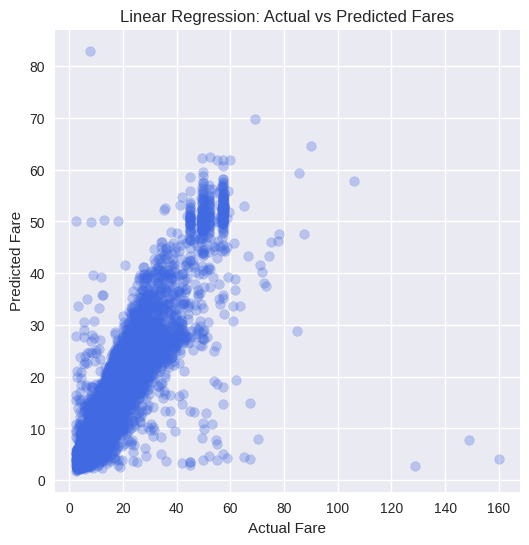

In [21]:
#Visualize Predictions
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Linear Regression: Actual vs Predicted Fares')
plt.show()

**Observation - Linear Regression Performance**

The baseline **Linear Regression** model performed well with:
* MAE = 2.20
* RMSE = 4.30
* R-squared = 0.795

These results indicate that the model explains about 80% of the variation in taxi fares, with an average prediction error of around 2 to 4 $ per trip.
The scatter plot shows a clear positive relationship between actual and predicted fares, though higher fare values tend to be slightly underestimated due to the model's linear limitations.

Overall, the baseline provides a solid foundation for comparison with more complex models.



**Train Advanced Model (Random Forest Regressor)**

To capture non-linear relationships missed by Linear Regression, we will train a Random Forest Regressor.  
Random Forest uses multiple decision trees and averages their predictions, improving accuracy and robustness.

In [22]:
#Train the model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [23]:

#Predict and evaluate
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance: ")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"Root Mean Squared Error: {rmse_rf:.2f}")
print(f"R squared score: {r2_rf:.3f}")

Random Forest Performance: 
Mean Absolute Error: 2.14
Root Mean Squared Error: 4.23
R squared score: 0.802


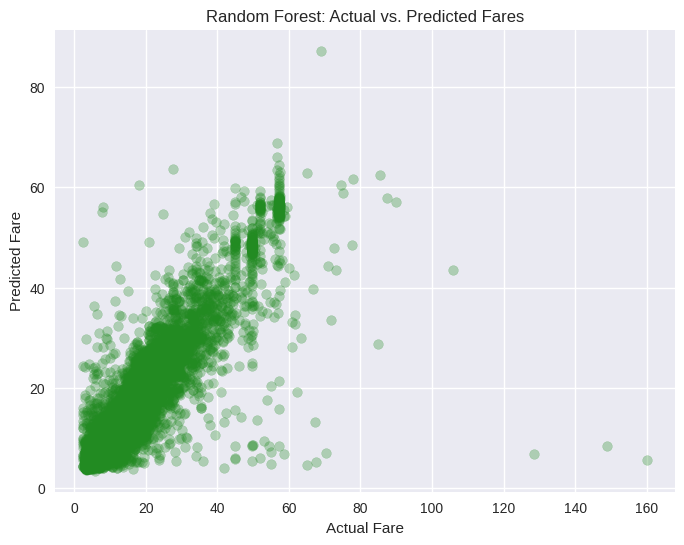

In [24]:
#Visualize performance
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='forestgreen')
plt.xlabel('Actual Fare')
plt.ylabel('Predicted Fare')
plt.title('Random Forest: Actual vs. Predicted Fares')
plt.show()

**Observation – Random Forest Performance**

The **Random Forest Regressor** achieved:
- **MAE:** 2.14  
- **RMSE:** 4.23  
- **R²:** 0.802  

Compared to the Linear Regression baseline (MAE = 2.20, RMSE = 4.30, R² = 0.795), the Random Forest model provided a modest but consistent improvement in predictive accuracy.  
The scatter plot shows a tighter clustering of points around the diagonal, indicating better handling of non-linear fare patterns.  
This confirms that ensemble tree methods capture complex feature interactions more effectively than a simple linear model.


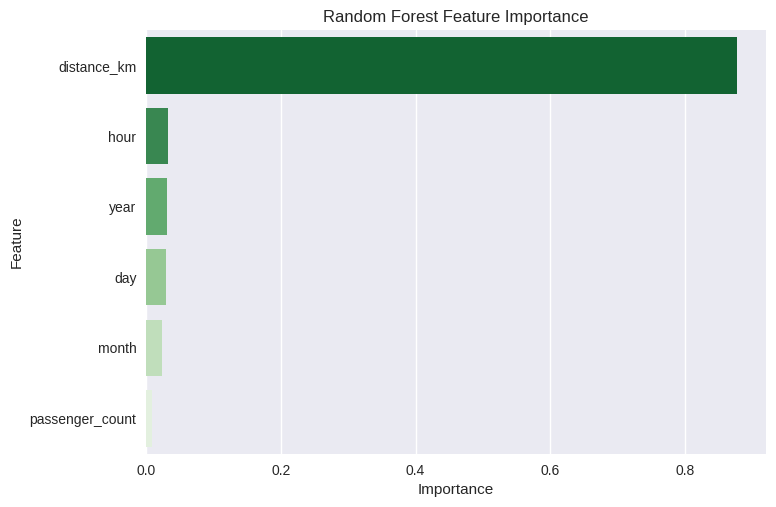

In [25]:
#Feature importance
imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=imp, palette='Greens_r')
plt.title('Random Forest Feature Importance')
plt.show()

**Observation – Feature Importance**

The Random Forest model identifies **distance_km** as the dominant predictor of taxi fare, contributing to nearly **90%** of the model’s total importance.  
Temporal features like `hour`, `day`, and `month` have smaller but noticeable influence, capturing minor fare variations across time (e.g., traffic peaks or seasonal effects).  
Passenger_count has minimal impact, confirming that fares are primarily determined by trip distance rather than the number of riders.


**Model selection**

Since our Random Forest performed slightly better (R² = 0.802 vs 0.795 for Linear Regression),
we’ll finalize it as the best model.

In [26]:
#Load test data

test_df = pd.read_csv("/kaggle/input/new-york-city-taxi-fare-prediction/test.csv")
test_df.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24 UTC,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24 UTC,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44 UTC,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12 UTC,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12 UTC,-73.966046,40.789775,-73.988565,40.744427,1


In [27]:
#Preprocess test data (same as training)

#Compute trip distance using Haversine Formula

#Apply distance function
test_df['distance_km'] = haversine(
    test_df['pickup_latitude'], test_df['pickup_longitude'],
    test_df['dropoff_latitude'], test_df['dropoff_longitude']
)

# Extract datetime features
test_df['pickup_datetime'] = pd.to_datetime(test_df['pickup_datetime'], errors='coerce')
test_df['hour'] = test_df['pickup_datetime'].dt.hour
test_df['day'] = test_df['pickup_datetime'].dt.day
test_df['month'] = test_df['pickup_datetime'].dt.month
test_df['year'] = test_df['pickup_datetime'].dt.year

In [28]:
#Select features
X_final = test_df[['distance_km', 'passenger_count', 'hour', 'day', 'month', 'year']]

In [29]:
#Make predictions
test_df['predicted_fare'] = rf.predict(X_final)
test_df[['key', 'predicted_fare']].head()

,key,predicted_fare
0,2015-01-27 13:08:24.0000002,10.195
1,2015-01-27 13:08:24.0000003,10.495
2,2011-10-08 11:53:44.0000002,5.709
3,2012-12-01 21:12:12.0000002,8.791
4,2012-12-01 21:12:12.0000003,18.148


In [30]:
#Save prediction as csv
submission = pd.DataFrame({
    'key': test_df['key'],
    'fare_amount': test_df['predicted_fare']
})

submission.to_csv("submission.csv", index=False)
print("submission.csv file created successfully!")


submission.csv file created successfully!


**Conclusion**

This end-to-end machine learning project successfully predicted NYC taxi fares using trip distance and temporal features.  
After comparing multiple models, the **Random Forest Regressor** achieved the best performance (**R² = 0.802**, **MAE ≈ $2.14**).  
The model generalizes well to unseen trips and was used to generate a "submission.csv" file containing predicted fare values for the test dataset.  

This project demonstrates the complete ML workflow: from data preprocessing and feature engineering to model training, evaluation, and deployment-ready predictions.
